In [38]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [39]:
sales = pd.read_parquet("D:\Sample Projects\PulseBoard\data\clean/clean_sales.parquet")

sales["date"] = pd.to_datetime(sales["date"])

sales["revenue"] = (
    sales["units"]
    * sales["unit_price"]
    * (1 - sales["discount_pct"]/100)
)

sales["profit"] = (
    sales["revenue"]
    - sales["cost_price"] * sales["units"]
)

In [41]:
monthly = (

    sales

    .groupby(

        [

            pd.Grouper(

                key="date",

                freq="M"

            ),

            "region"

        ]

    )["revenue"]

    .sum()

    .reset_index()

)

In [42]:
monthly["rolling"] = (

    monthly

    .groupby("region")["revenue"]

    .transform(

        lambda x:

        x.rolling(3).mean()

    )

)

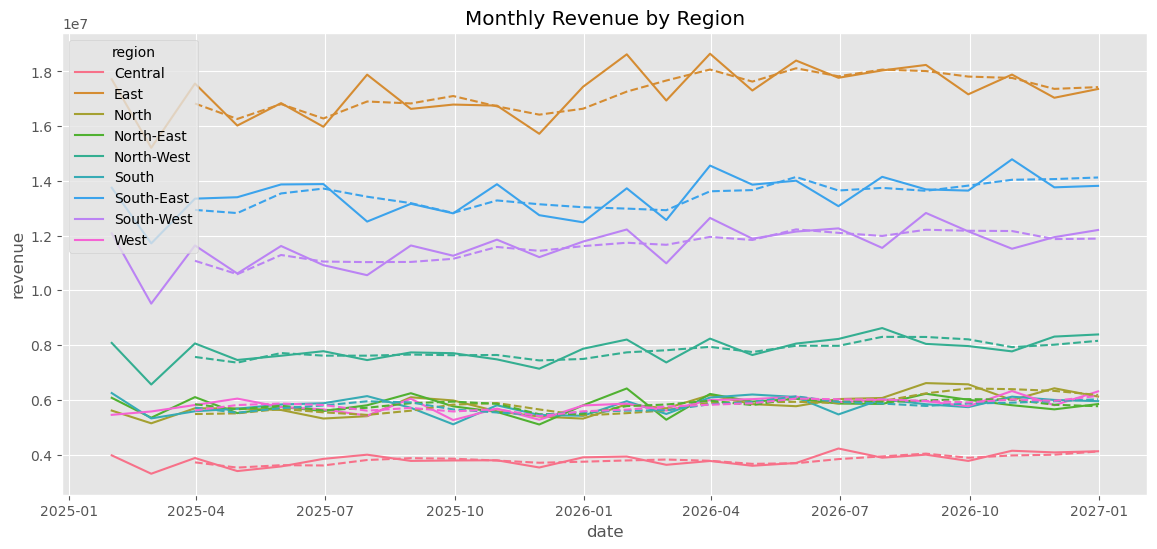

In [43]:
plt.figure(figsize=(14,6))

sns.lineplot(

    data=monthly,

    x="date",

    y="revenue",

    hue="region"

)

sns.lineplot(

    data=monthly,

    x="date",

    y="rolling",

    hue="region",

    legend=False,

    linestyle="--"

)

plt.title("Monthly Revenue by Region")

plt.show()

In [44]:
trend = (

    monthly

    .groupby("region")

    .apply(

        lambda x:

        (

            x.iloc[-1]["revenue"]

            -

            x.iloc[0]["revenue"]

        )

        /

        x.iloc[0]["revenue"]

        *100

    )

)

print(trend.sort_values())

region
South         -4.761864
North-East    -3.757108
East          -2.006006
South-East     0.499514
South-West     1.009749
Central        3.764487
North-West     3.831351
North          9.120145
West          15.738463
dtype: float64


In [45]:
daily = (

    sales

    .groupby(

        "date"

    )["footfall"]

    .sum()

    .reset_index()

)

In [46]:
print(sales.columns)

Index(['transaction_id', 'store_id', 'product_id', 'units', 'unit_price',
       'discount_pct', 'payment_type', 'currency', 'date', 'region', 'city',
       'sqft', 'opened_date', 'category', 'sub_category', 'cost_price',
       'launch_date', 'reason', 'return_date', 'footfall', 'revenue',
       'profit'],
      dtype='object')


In [47]:
daily["weekday"] = daily["date"].dt.day_name()

daily["month"] = daily["date"].dt.month_name()

In [48]:
weekly = (

    daily

    .groupby("weekday")["footfall"]

    .mean()

)

In [49]:
monthly = (

    daily

    .groupby("month")["footfall"]

    .mean()

)

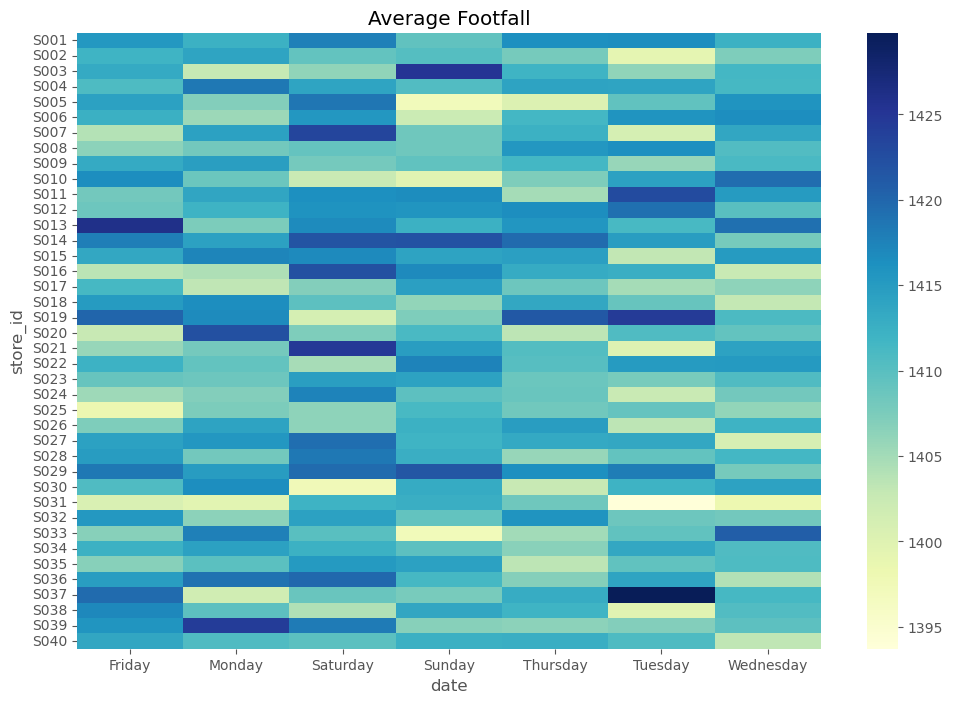

In [50]:
heat = (

    sales

    .groupby(

        [

            "store_id",

            sales["date"].dt.day_name()

        ]

    )["footfall"]

    .mean()

    .unstack()

)

plt.figure(figsize=(12,8))

sns.heatmap(

    heat,

    cmap="YlGnBu"

)

plt.title("Average Footfall")

plt.show()

In [51]:
daily = (

    sales

    .groupby(

        ["date","store_id"]

    )["revenue"]

    .sum()

    .reset_index()

)

In [81]:
store = daily[daily.store_id=="S001"].copy()

In [83]:
store["rolling"] = (

    store["revenue"]

    .rolling(30)

    .mean()

)

store["std"] = (

    store["revenue"]

    .rolling(30)

    .std()

)

In [84]:
store["anomaly"] = np.where(

    np.abs(

        store["revenue"]

        -

        store["rolling"]

    )

    >

    3*store["std"],

    True,

    False

)

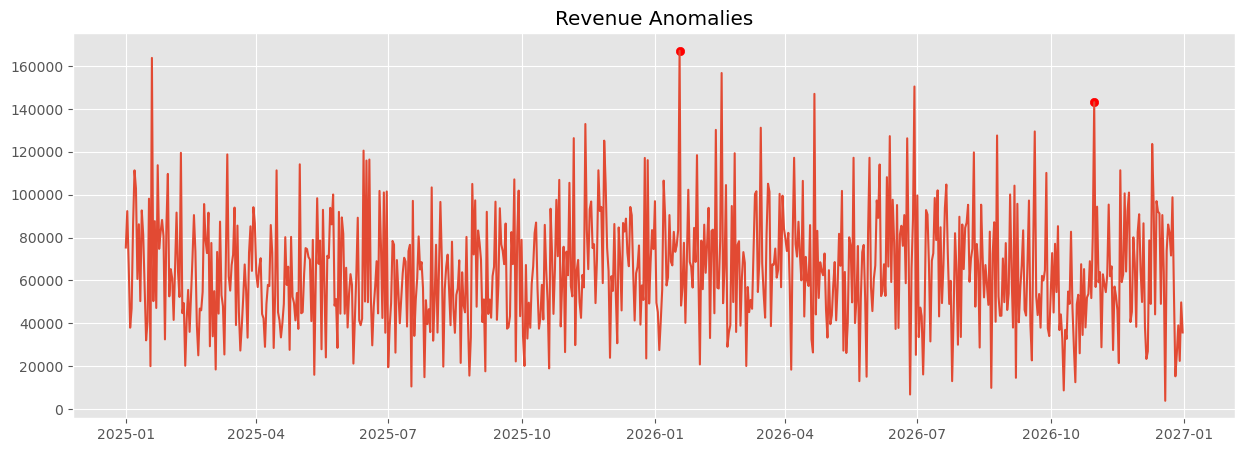

In [86]:
plt.figure(figsize=(15,5))

plt.plot(

    store["date"],

    store["revenue"]

)

plt.scatter(

    store.loc[store.anomaly,"date"],

    store.loc[store.anomaly,"revenue"],

    color="red"

)

plt.title("Revenue Anomalies")

plt.show()

In [59]:
profit = (

    sales

    .groupby("product_id")["profit"]

    .sum()

    .sort_values(

        ascending=False

    )

)

In [60]:
cum = (

    profit.cumsum()

    /

    profit.sum()

)

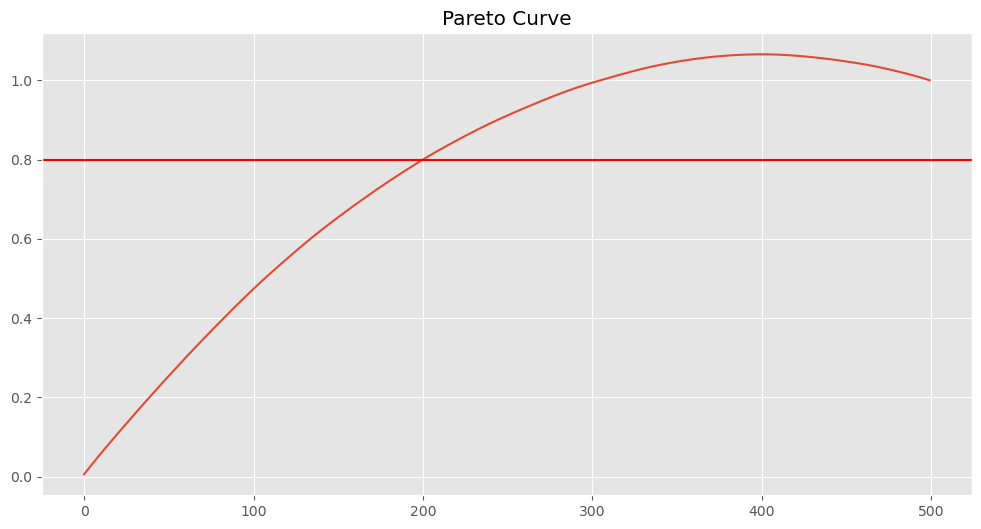

In [61]:
plt.figure(figsize=(12,6))

plt.plot(cum.values)

plt.axhline(

    0.8,

    color="red"

)

plt.title("Pareto Curve")

plt.show()

In [63]:
percent = (

    (cum<=0.8)

    .sum()

    /

    len(cum)

)*100

print(percent)

40.0


In [65]:
top = (

    sales

    .groupby("store_id")["revenue"]

    .sum()

    .nlargest(3)

    .index

)

In [68]:
for s in top:

    temp = (

        sales

        [sales.store_id==s]

        .groupby("date")

        [["footfall","revenue"]]

        .sum()

    )

    print(f"Store: {s}")

    for lag in range(-7,8):

        corr = temp["footfall"].corr(

            temp["revenue"].shift(lag)

        )

        print(f"Lag: {lag}, Correlation: {corr}")

Store: S028
Lag: -7, Correlation: -0.004688884495019053
Lag: -6, Correlation: -0.029603594657937563
Lag: -5, Correlation: -0.04578047650437708
Lag: -4, Correlation: -0.026321337404954154
Lag: -3, Correlation: -0.0001643421053987534
Lag: -2, Correlation: -0.008419731416670373
Lag: -1, Correlation: 0.051498824002536574
Lag: 0, Correlation: 0.75008603384123
Lag: 1, Correlation: 0.0574116030901416
Lag: 2, Correlation: -0.0207207305221379
Lag: 3, Correlation: -0.033993175879670726
Lag: 4, Correlation: -0.0142822952084065
Lag: 5, Correlation: -0.009615600888849779
Lag: 6, Correlation: 0.012388679179301887
Lag: 7, Correlation: 0.03648809023698418
Store: S017
Lag: -7, Correlation: 0.011593761980777962
Lag: -6, Correlation: 0.02564604428431609
Lag: -5, Correlation: -0.01838041034940156
Lag: -4, Correlation: -0.01610948905862879
Lag: -3, Correlation: -0.044337690694698034
Lag: -2, Correlation: -0.0017428600461486523
Lag: -1, Correlation: 0.025842969461192834
Lag: 0, Correlation: 0.72920398758414

In [69]:
sales["returned"] = (

    sales["return_date"]

    .notna()

)

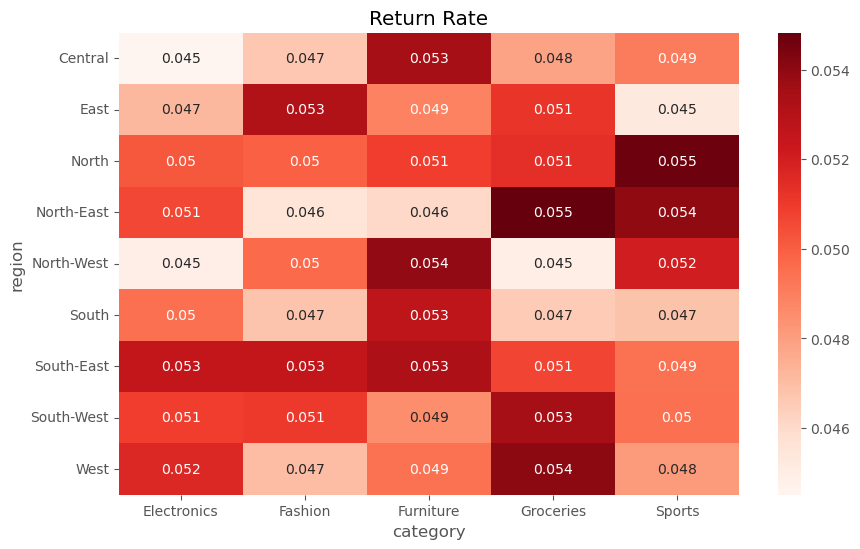

In [70]:
risk = (

    sales

    .groupby(

        [

            "region",

            "category"

        ]

    )["returned"]

    .mean()

    .unstack()

)

plt.figure(figsize=(10,6))

sns.heatmap(

    risk,

    annot=True,

    cmap="Reds"

)

plt.title("Return Rate")

plt.show()

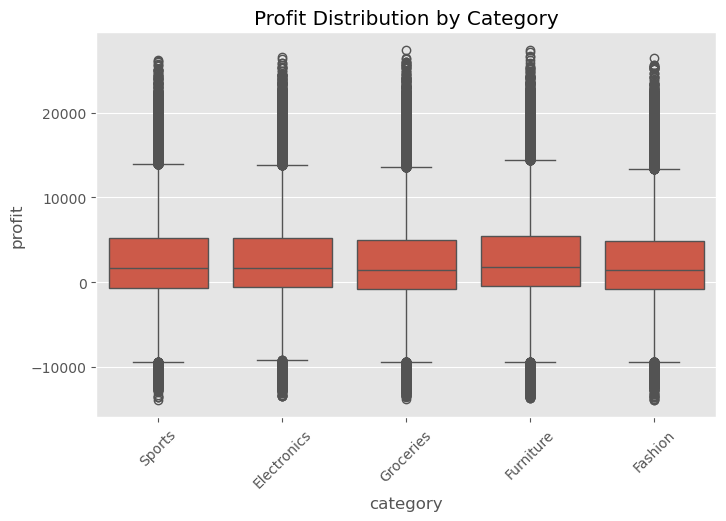

In [72]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=sales,
    x="category",
    y="profit"
)

plt.title("Profit Distribution by Category")
plt.xticks(rotation=45)
plt.show()

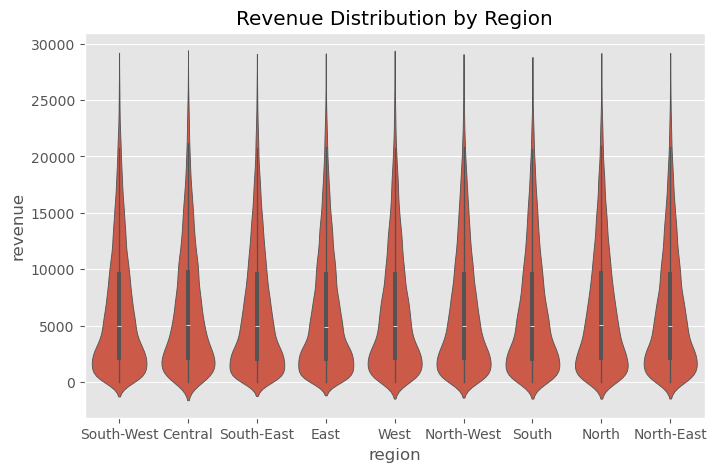

In [73]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=sales,
    x="region",
    y="revenue"
)

plt.title("Revenue Distribution by Region")
plt.show()

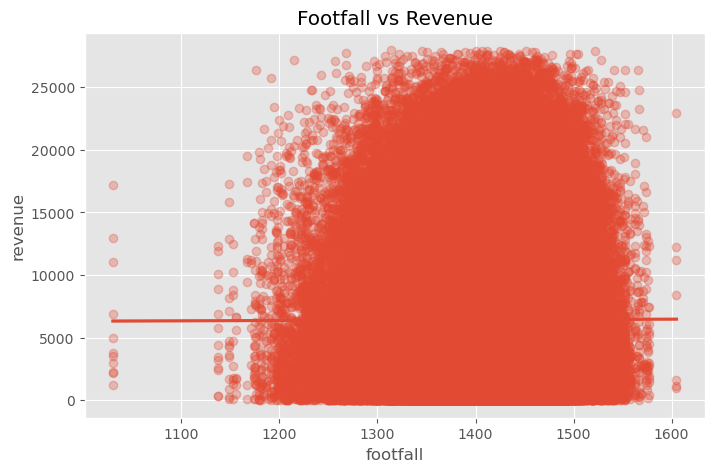

In [74]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=sales,
    x="footfall",
    y="revenue",
    scatter_kws={"alpha":0.3}
)

plt.title("Footfall vs Revenue")
plt.show()

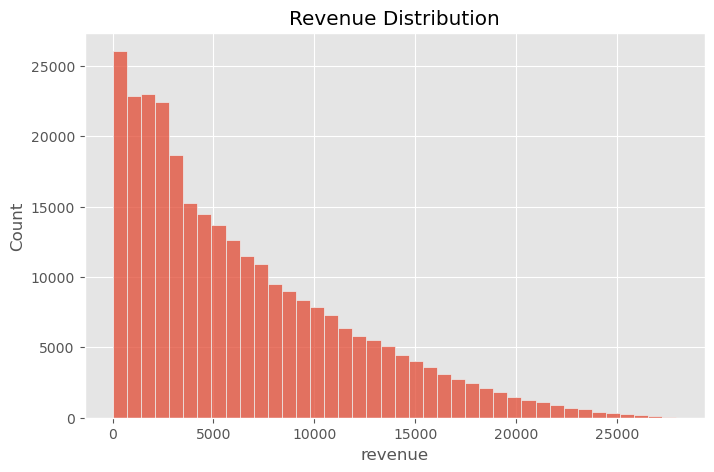

In [75]:
plt.figure(figsize=(8,5))

sns.histplot(
    sales["revenue"],
    bins=40
)

plt.title("Revenue Distribution")
plt.show()